# Model Evaluation

Evaluates `OrdinalPairClassifier` on the held-out test split. Covers accuracy, MAE, confusion matrices, error distributions, per-bucket breakdowns, and qualitative examples.

In [20]:
import sys
from pathlib import Path

# Add ChordEdit root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader

from models.classification.model import OrdinalPairClassifier
from models.classification.head_coral import decode_ordinal
from models.classification.head_mse import decode_regression
from models.classification.head_mae import mae_buckets
from models.classification.classify import PairDataset, collate, eval_loader

from settings import *


### 1. Load Data

In [2]:
from models.classification.settings import OUTPUTS_DIR

run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories found in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
print(f"Using run: {RUN_DIR.name}")

train_df = pd.read_parquet(RUN_DIR / "train.parquet.gz")
val_df   = pd.read_parquet(RUN_DIR / "val.parquet.gz")
test_df  = pd.read_parquet(RUN_DIR / "test.parquet.gz")

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"t_start buckets: {sorted(train_df['t_start'].unique())}")
print(f"t_end   buckets: {sorted(train_df['t_end'].unique())}")
test_df

Using run: 20260623_090326
train: 560  val: 70  test: 70
t_start buckets: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
t_end   buckets: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7)]


,sample_id,t_start,t_end,id,source_prompt,target_prompt,t_start_idx,t_end_idx
0,000000000004,0.8,0.2,000000000004,a cat sitting next to a mirror,a [silver] cat [sculpture] sitting next to a m...,8,2
1,000000000013,0.7,0.2,000000000013,three white [dumplings] on brown bowl,three white [sushi] on brown bowl,7,2
2,000000000014,0.9,0.2,000000000014,a man with his hands [hanging down] standing b...,a man with his hands [rasing] standing by a house,9,2
3,000000000027,0.9,0.3,000000000027,a [opened] eyes cat sitting on wooden floor,a [closed] eyes cat sitting on wooden floor,9,3
4,000000000032,0.9,0.0,000000000032,a group of [pink] flowers hanging from a tree,a group of [red] flowers hanging from a tree,9,0
...,...,...,...,...,...,...,...,...
65,913000000006,0.7,0.3,913000000006,"a desk with a laptop, a plant, and a mouse","[a brush painting of] a desk with a laptop, a ...",7,3
66,921000000001,0.7,0.3,921000000001,a rat is peeking out from behind a pink wall,[a digital art of] a rat is peeking out from b...,7,3
67,921000000003,1.0,0.2,921000000003,a bernese mountain dog is sitting in the grass,[stained glass window of] a bernese mountain d...,10,2
68,924000000003,0.1,0.0,924000000003,wind turbine in the sunset,[pen and ink sketch of] wind turbine in the su...,1,0


### 2. Load Model

In [3]:
from models.classification.settings import FREEZE_ENCODER

weights_path = RUN_DIR / "classifier_weights.pt"
assert weights_path.exists(), f"No weights found in {RUN_DIR}"
print(f"Loading: {weights_path}  (run: {RUN_DIR.name})\n")

ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
buckets_start = torch.tensor(ckpt["buckets1"], dtype=torch.float)
buckets_end   = torch.tensor(ckpt["buckets2"], dtype=torch.float)
HEAD_TYPE     = ckpt.get("config", {}).get("HEAD_TYPE", "CORAL")

print("Checkpoint settings:")
for k, v in ckpt.get("config", {}).items():
    print(f"  {k:<25} {v}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrdinalPairClassifier(
    buckets1=buckets_start, buckets2=buckets_end,
    freeze_encoder=FREEZE_ENCODER, head_type=HEAD_TYPE,
).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"\nDevice: {DEVICE}")

bucket_vals_start = buckets_start.numpy()
bucket_vals_end   = buckets_end.numpy()
N_BUCKETS_START   = len(bucket_vals_start)
N_BUCKETS_END     = len(bucket_vals_end)
BUCKET_LABELS_START = [f"{v:.3g}" for v in bucket_vals_start]
BUCKET_LABELS_END   = [f"{v:.3g}" for v in bucket_vals_end]
print(f"t_start: {N_BUCKETS_START} buckets {BUCKET_LABELS_START}")
print(f"t_end:   {N_BUCKETS_END} buckets {BUCKET_LABELS_END}")

Loading: /data/home/mirick/ChordEdit/models/classification/outputs/sdturbo/20260623_090326/classifier_weights.pt  (run: 20260623_090326)

Checkpoint settings:
  run_dir                   /data/home/mirick/ChordEdit/models/classification/outputs/sdturbo/20260623_090326
  PARENT_DIR                /data/home/mirick/ChordEdit/models/classification
  DATA_DIR                  /data/home/mirick/ChordEdit/models/classification/data
  METRICS_CSV               /data/home/mirick/ChordEdit/models/classification/data/id_to_metrics_sdturbo.csv
  STRINGS_CSV               /data/home/mirick/ChordEdit/models/classification/data/id_to_string_pair.csv
  OUTPUTS_SUBDIR            sdturbo
  OUTPUTS_DIR               /data/home/mirick/ChordEdit/models/classification/outputs/sdturbo
  N_BUCKETS_START           11
  N_BUCKETS_END             11
  PAPER_T_START             0.9
  PAPER_T_END               0.3
  PAPER_T_DELTA             0.15
  COMPUTED_METRIC_FN        compute_naive_pareto_score
  COMPUTED_M

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7208.15it/s]



Device: cuda
t_start: 11 buckets ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']
t_end:   8 buckets ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7']


### 3. Run Inference on All Splits

In [4]:
from models.classification.settings import BATCH_SIZE

def predict_split(df: pd.DataFrame) -> dict:
    """Return dict with pred/true arrays for both heads."""
    loader = DataLoader(PairDataset(df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    p1_list, p2_list, l1_list, l2_list = [], [], [], []
    raw1_list, raw2_list = [], []
    with torch.no_grad():
        for srcs, tgts, l1, l2 in loader:
            l1, l2 = l1.to(DEVICE), l2.to(DEVICE)
            out1, out2 = model(srcs, tgts)
            if model.head_type == "CORAL":
                p1_list.append(decode_ordinal(out1).cpu())
                p2_list.append(decode_ordinal(out2).cpu())
            else:
                p1_list.append(decode_regression(out1, model.buckets1).cpu())
                p2_list.append(decode_regression(out2, model.buckets2).cpu())
            raw1_list.append(out1.cpu())
            raw2_list.append(out2.cpu())
            l1_list.append(l1.cpu())
            l2_list.append(l2.cpu())
    return {
        "pred_start": torch.cat(p1_list).numpy(),
        "pred_end":   torch.cat(p2_list).numpy(),
        "true_start": torch.cat(l1_list).numpy(),
        "true_end":   torch.cat(l2_list).numpy(),
        "raw_start":  torch.cat(raw1_list).numpy(),
        "raw_end":    torch.cat(raw2_list).numpy(),
    }

results = {
    "train": predict_split(train_df),
    "val":   predict_split(val_df),
    "test":  predict_split(test_df),
}
print("Inference complete.")

Inference complete.


### 4. Metrics Summary

In [5]:
def compute_metrics(r: dict) -> dict:
    p1 = torch.tensor(r["pred_start"])
    p2 = torch.tensor(r["pred_end"])
    t1 = torch.tensor(r["true_start"])
    t2 = torch.tensor(r["true_end"])
    return {
        "mae_start":  mae_buckets(p1, t1).item(),
        "mae_end":    mae_buckets(p2, t2).item(),
        "acc_start":  (p1 == t1).float().mean().item(),
        "acc_end":    (p2 == t2).float().mean().item(),
        "acc_both":   ((p1 == t1) & (p2 == t2)).float().mean().item(),
    }

metrics_df = pd.DataFrame(
    {split: compute_metrics(r) for split, r in results.items()}
).T.rename(columns={
    "mae_start": "MAE t_start",
    "mae_end":   "MAE t_end",
    "acc_start": "Acc t_start",
    "acc_end":   "Acc t_end",
    "acc_both":  "Joint Acc",
})
metrics_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=0)

,MAE t_start,MAE t_end,Acc t_start,Acc t_end,Joint Acc
train,1.630,1.346,0.275,0.193,0.048
val,2.843,1.743,0.114,0.071,0.000
test,2.614,1.371,0.086,0.200,0.029


### 5. Metrics Across Splits (Bar Chart)

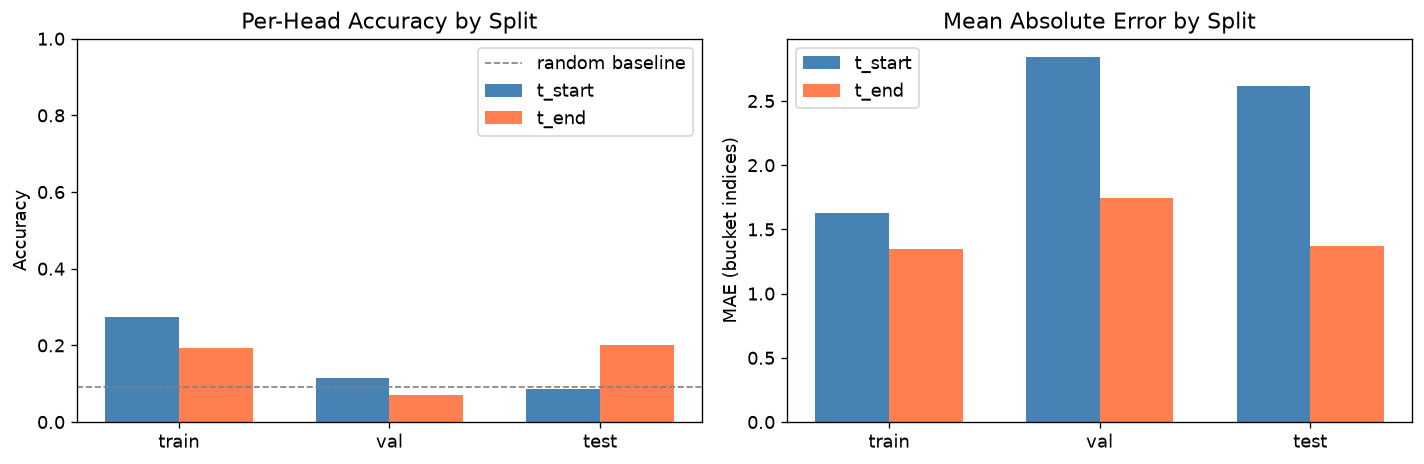

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = ["train", "val", "test"]
x = np.arange(len(splits))
width = 0.35

# Accuracy panel
ax = axes[0]
m = {s: compute_metrics(results[s]) for s in splits}
ax.bar(x - width/2, [m[s]["acc_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["acc_end"]   for s in splits], width, label="t_end",   color="coral")
ax.axhline(1/N_BUCKETS_START, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Accuracy"); ax.set_title("Per-Head Accuracy by Split")
ax.set_ylim(0, 1); ax.legend()

# MAE panel
ax = axes[1]
ax.bar(x - width/2, [m[s]["mae_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["mae_end"]   for s in splits], width, label="t_end",   color="coral")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("MAE (bucket indices)"); ax.set_title("Mean Absolute Error by Split")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/metrics_by_split.png", bbox_inches="tight")
plt.show()

### 6. Confusion Matrices (Test Set)

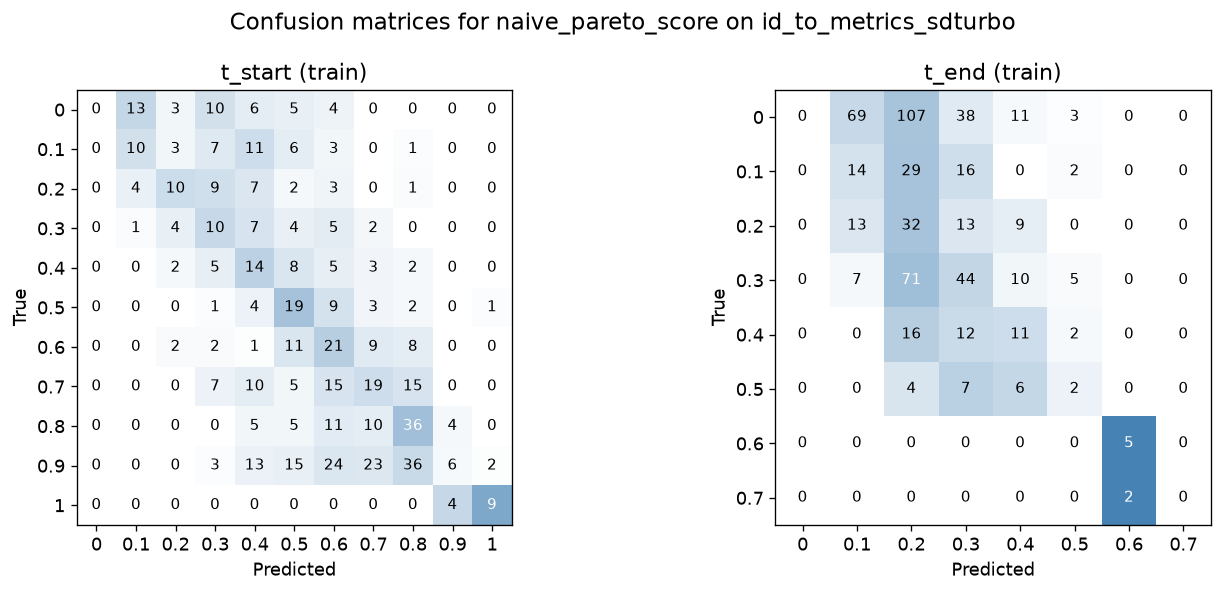

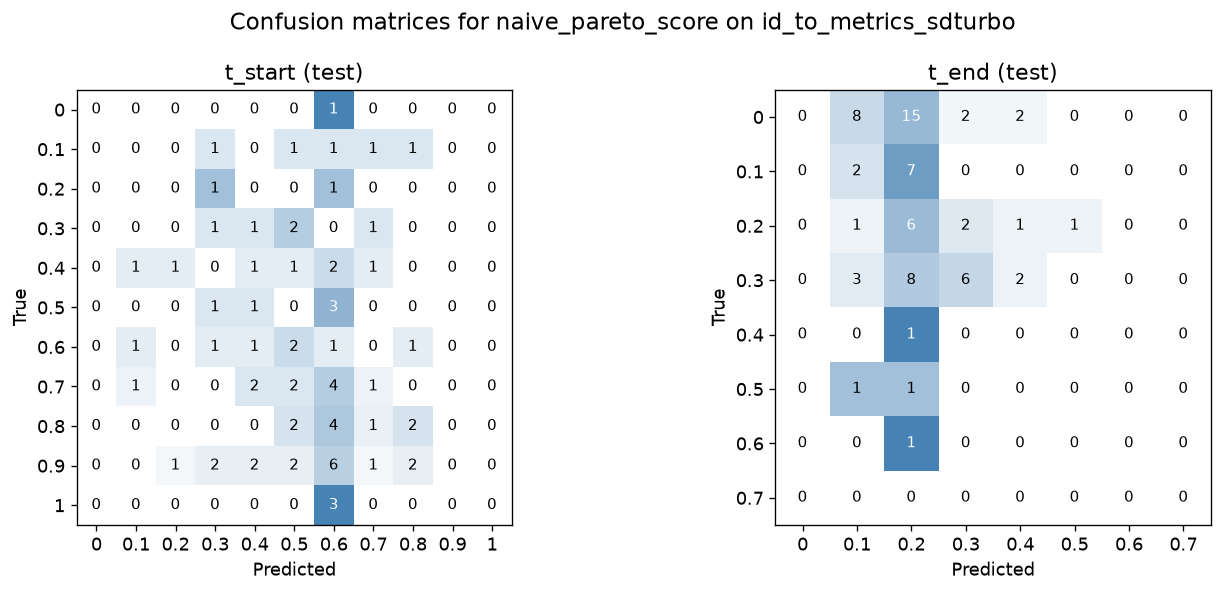

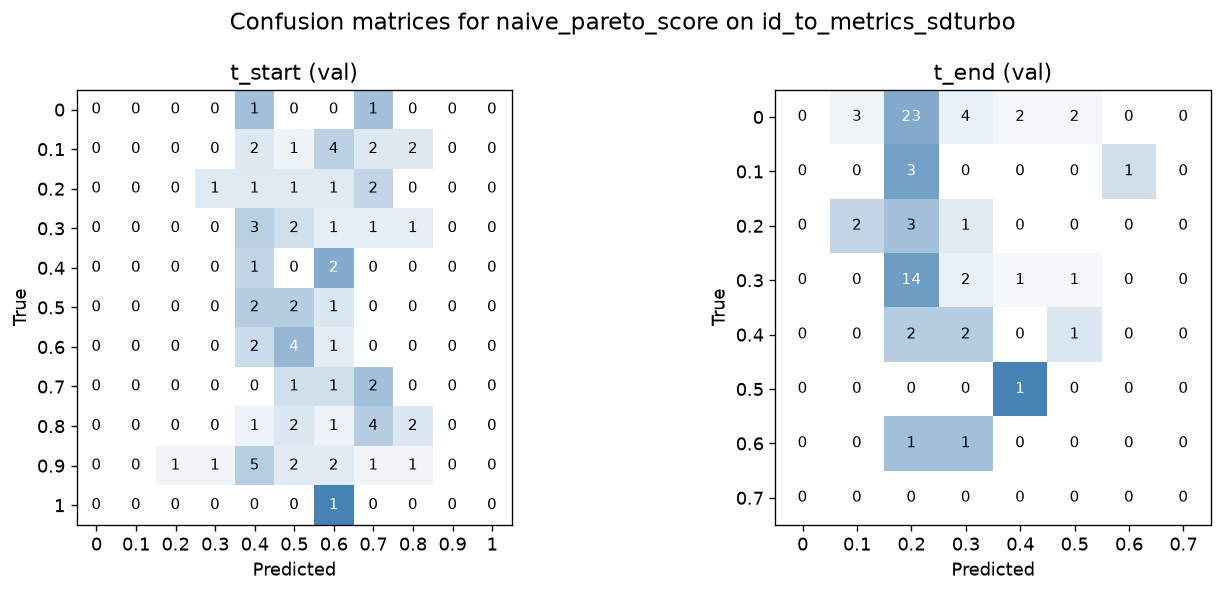

In [27]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title, bucket_labels):
    n_buckets = len(bucket_labels)

    cm = confusion_matrix(true, pred, labels=list(range(n_buckets)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

    for i in range(n_buckets):
        for j in range(n_buckets):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=9, color="white" if cm_norm[i, j] > 0.5 else "black")

    ax.set_xticks(range(n_buckets))
    ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels)
    ax.set_yticklabels(bucket_labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    return im

def plot_split(split):
    r = results[split]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_confusion(axes[0], r["true_start"], r["pred_start"], f"t_start ({split})", BUCKET_LABELS_START)
    plot_confusion(axes[1], r["true_end"], r["pred_end"], f"t_end ({split})", BUCKET_LABELS_END)
    fig.suptitle(f"Confusion matrices for {COMPUTED_METRIC_COL} on {METRICS_CSV.stem}", fontsize=14)

    plt.tight_layout()  # leave space for suptitle
    plt.savefig(f"outputs/confusion_matrices_{split}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

for split in ["train", "test", "val"]:
    plot_split(split)

### 7. Error Distribution

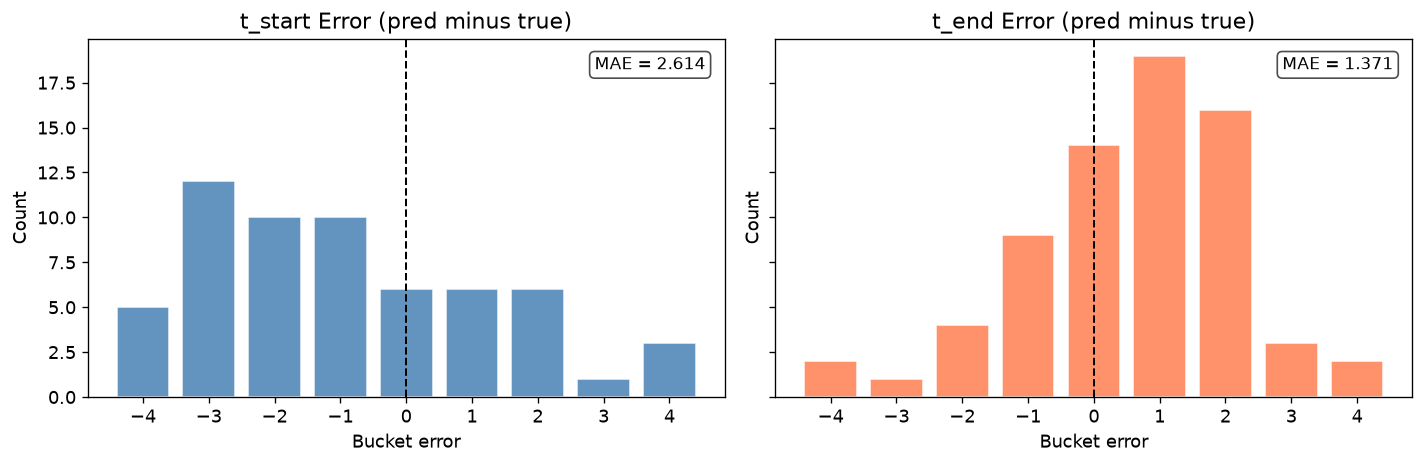

In [8]:
r = results["test"]
err_start = r["pred_start"] - r["true_start"]
err_end   = r["pred_end"]   - r["true_end"]

bins = np.arange(-4.5, 5.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, err, title, color in [
    (axes[0], err_start, "t_start Error (pred minus true)", "steelblue"),
    (axes[1], err_end,   "t_end Error (pred minus true)",   "coral"),
]:
    counts, edges = np.histogram(err, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, counts, width=0.8, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Bucket error")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    mae_val = np.abs(err).mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.savefig("outputs/error_distribution.png", bbox_inches="tight")
plt.show()

### 8. Predicted vs. True Class Distributions

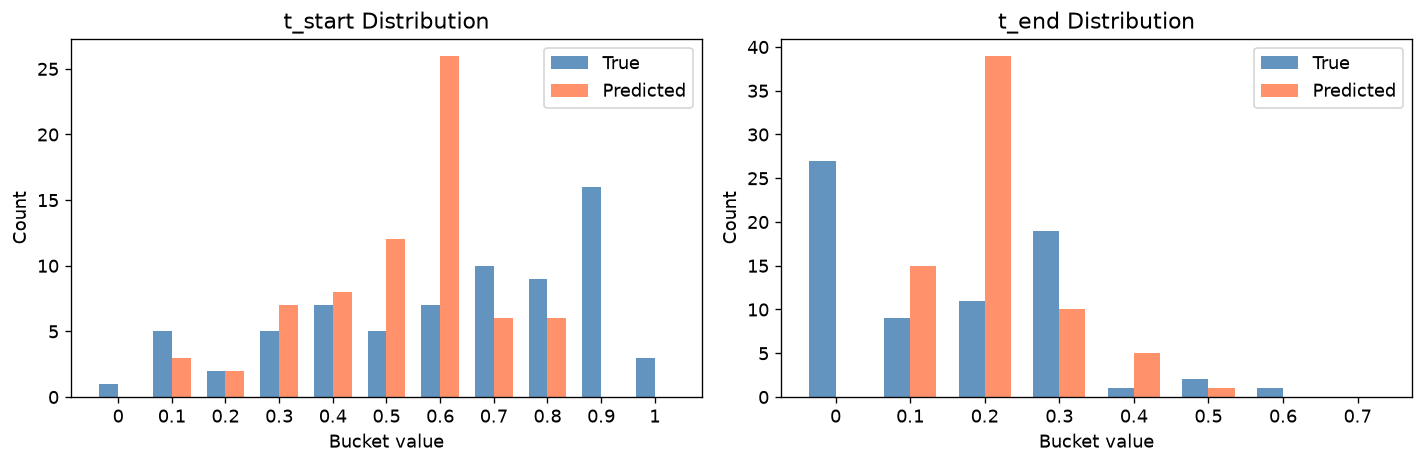

In [9]:
r = results["test"]
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "t_start Distribution", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "t_end Distribution",   N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    x = np.arange(n_buckets)
    true_counts = np.bincount(r[true_key], minlength=n_buckets)
    pred_counts = np.bincount(r[pred_key], minlength=n_buckets)
    ax.bar(x - width/2, true_counts, width, label="True",      color="steelblue", alpha=0.85)
    ax.bar(x + width/2, pred_counts, width, label="Predicted", color="coral",     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("Bucket value"); ax.set_ylabel("Count")
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/class_distribution.png", bbox_inches="tight")
plt.show()

### 9. Per-Bucket Accuracy

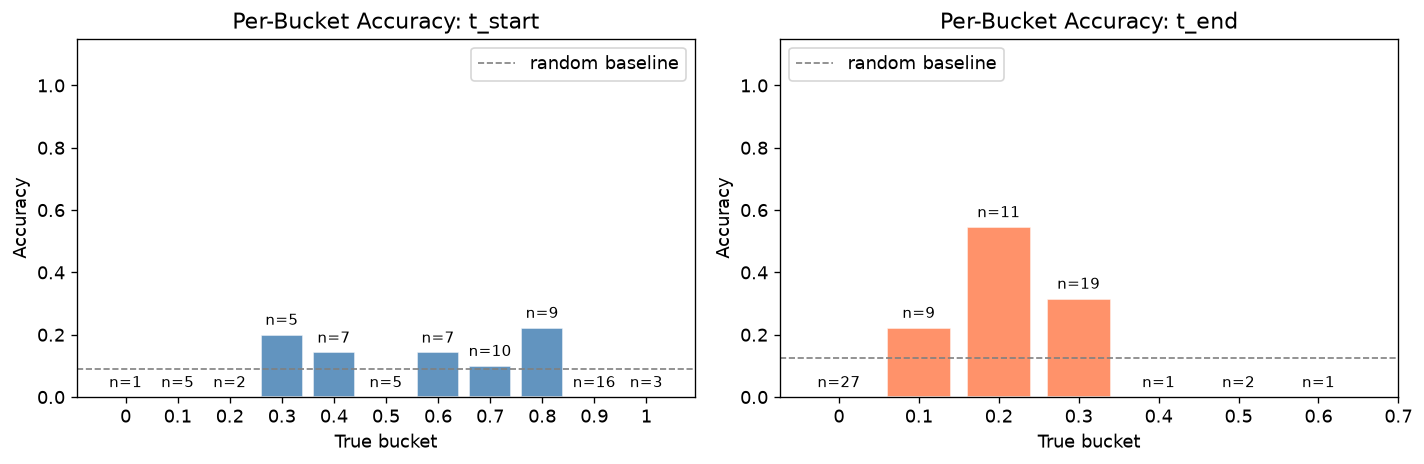

In [10]:
r = results["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "Per-Bucket Accuracy: t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "Per-Bucket Accuracy: t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    accs, counts = [], []
    for bucket in range(n_buckets):
        mask = r[true_key] == bucket
        n = mask.sum()
        acc = (r[pred_key][mask] == bucket).mean() if n > 0 else float("nan")
        accs.append(acc)
        counts.append(n)
    bars = ax.bar(range(n_buckets), accs, color=color, alpha=0.85, edgecolor="white")
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"n={n}", ha="center", va="bottom", fontsize=9)
    ax.axhline(1/n_buckets, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_xticks(range(n_buckets)); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.15); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/per_bucket_accuracy.png", bbox_inches="tight")
plt.show()

### 10. Scatter: Predicted vs. True Bucket Indices

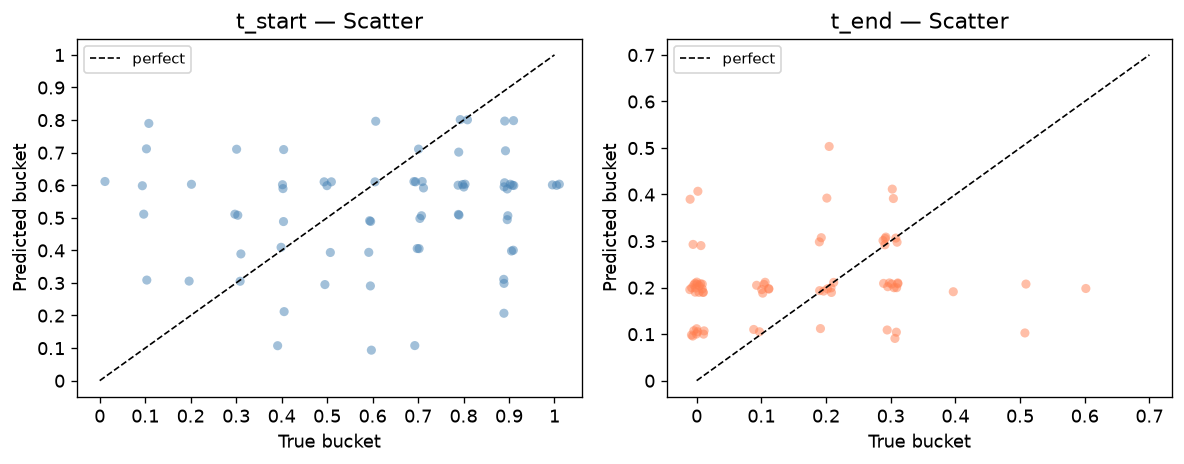

In [11]:
r = results["test"]
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    jx = r[true_key] + rng.uniform(-jitter, jitter, len(r[true_key]))
    jy = r[pred_key] + rng.uniform(-jitter, jitter, len(r[pred_key]))
    ax.scatter(jx, jy, alpha=0.5, s=30, color=color, edgecolors="none")
    ax.plot([0, n_buckets - 1], [0, n_buckets - 1], "k--", linewidth=1, label="perfect")
    ax.set_xticks(range(n_buckets)); ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels); ax.set_yticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Predicted bucket")
    ax.set_title(f"{title} — Scatter")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/scatter_pred_vs_true.png", bbox_inches="tight")
plt.show()

## 11. Head Internals

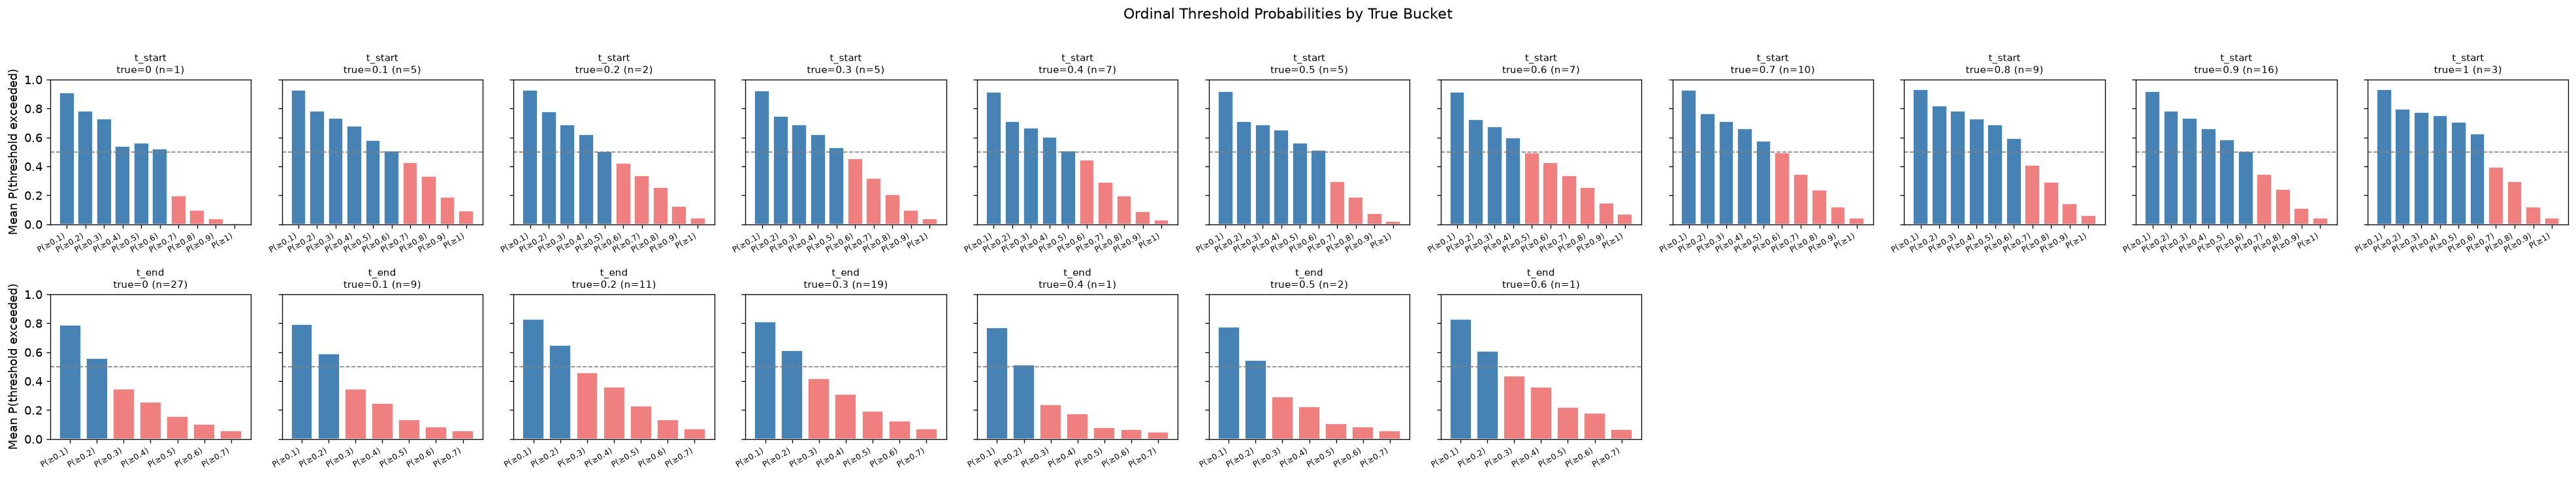

In [12]:
def sigmoid(x): return 1 / (1 + np.exp(-x))

r = results["test"]

if model.head_type == "CORAL":
    # --- CORAL: average sigmoid(logit) per threshold, grouped by true bucket ---
    logits1 = r["raw_start"]   # (N, N_BUCKETS_START-1)
    logits2 = r["raw_end"]     # (N, N_BUCKETS_END-1)
    true1   = r["true_start"]
    true2   = r["true_end"]

    threshold_labels_start = [f"P(≥{v:.3g})" for v in bucket_vals_start[1:]]
    threshold_labels_end   = [f"P(≥{v:.3g})" for v in bucket_vals_end[1:]]

    n_cols = max(N_BUCKETS_START, N_BUCKETS_END)
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6), sharey=True)

    for head_idx, (logits, true, head_name, n_buckets, bucket_labels, thr_labels) in enumerate([
        (logits1, true1, "t_start", N_BUCKETS_START, BUCKET_LABELS_START, threshold_labels_start),
        (logits2, true2, "t_end",   N_BUCKETS_END,   BUCKET_LABELS_END,   threshold_labels_end),
    ]):
        for bucket in range(n_buckets):
            ax = axes[head_idx][bucket]
            mask = true == bucket
            if mask.sum() == 0:
                ax.set_visible(False)
                continue
            probs = sigmoid(logits[mask]).mean(axis=0)  # (n_buckets-1,)
            colors = ["steelblue" if p > 0.5 else "lightcoral" for p in probs]
            ax.bar(range(n_buckets - 1), probs, color=colors, edgecolor="white")
            ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
            ax.set_xticks(range(n_buckets - 1))
            ax.set_xticklabels(thr_labels, fontsize=7, rotation=30, ha="right")
            ax.set_ylim(0, 1)
            ax.set_title(f"{head_name}\ntrue={bucket_labels[bucket]} (n={mask.sum()})", fontsize=9)
            if bucket == 0:
                ax.set_ylabel("Mean P(threshold exceeded)")
        for bucket in range(n_buckets, n_cols):
            axes[head_idx][bucket].set_visible(False)

    plt.suptitle("Ordinal Threshold Probabilities by True Bucket", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("outputs/threshold_probs.png", bbox_inches="tight")
    plt.show()

else:
    # --- MSE: raw predicted scalar (sigmoid output) vs true bucket value ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, raw_key, true_key, head_name, n_buckets, bucket_vals, bucket_labels, color in [
        (axes[0], "raw_start", "true_start", "t_start", N_BUCKETS_START, bucket_vals_start, BUCKET_LABELS_START, "steelblue"),
        (axes[1], "raw_end",   "true_end",   "t_end",   N_BUCKETS_END,   bucket_vals_end,   BUCKET_LABELS_END,   "coral"),
    ]:
        raw  = r[raw_key]    # (N,) sigmoid scalars
        true = r[true_key]   # (N,) bucket indices

        # Box-per-true-bucket of raw predicted values
        data_by_bucket = [raw[true == b] for b in range(n_buckets)]
        bp = ax.boxplot(data_by_bucket, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        # Overlay the true bucket values as horizontal reference lines
        for i, v in enumerate(bucket_vals):
            ax.axhline(v, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_xticks(range(1, n_buckets + 1))
        ax.set_xticklabels(bucket_labels)
        ax.set_xlabel("True bucket")
        ax.set_ylabel("Raw predicted value (sigmoid output)")
        ax.set_title(f"{head_name} — Predicted scalar by true bucket")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig("outputs/regression_raw_by_bucket.png", bbox_inches="tight")
    plt.show()

## 12. Qualitative Examples

In [13]:
r = results["test"]

test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["pred_start"] = bucket_vals_start[r["pred_start"]]
test_df_copy["pred_end"]   = bucket_vals_end[r["pred_end"]]
test_df_copy["err_start"]  = abs(r["pred_start"] - r["true_start"])
test_df_copy["err_end"]    = abs(r["pred_end"]   - r["true_end"])
test_df_copy["max_err"]    = test_df_copy[["err_start", "err_end"]].max(axis=1)

# Show: 4 correct predictions and 4 worst mistakes
correct = test_df_copy[(test_df_copy.err_start == 0) & (test_df_copy.err_end == 0)].head(4)
wrong   = test_df_copy.sort_values("max_err", ascending=False).head(4)

def show_examples(df, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for _, row in df.iterrows():
        print(f"  source: {row['source_prompt'][:80]}")
        print(f"  target: {row['target_prompt'][:80]}")
        print(f"  t_start  true={row['t_start']:.3g}  pred={row['pred_start']:.3g}")
        print(f"  t_end    true={row['t_end']:.3g}  pred={row['pred_end']:.3g}")
        print()

show_examples(correct, "Correct predictions")
show_examples(wrong,   "Largest errors")


  Correct predictions
  source: a pot and a jar sitting on a counter [in a room]
  target: a pot and a jar sitting on a counter [in a garden]
  t_start  true=0.4  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a bride standing [on a mountain]
  target: a bride standing [in a garden]
  t_start  true=0.8  pred=0.8
  t_end    true=0.3  pred=0.3


  Largest errors
  source: a kitten
  target: a kitten [sculpture]
  t_start  true=0.1  pred=0.8
  t_end    true=0  pred=0.4

  source: a cartoon man sitting at a desk with [laptop]
  target: a cartoon man sitting at a desk with [notebook]
  t_start  true=0.9  pred=0.2
  t_end    true=0  pred=0.2

  source: notebook, pencil, glasses, camera on a map
  target: notebook, pencil, glasses, camera [and coffee] on a map
  t_start  true=0.1  pred=0.7
  t_end    true=0  pred=0.3

  source: a woman in a [brown] jacket and jeans
  target: a woman in a [black] jacket and jeans
  t_start  true=0  pred=0.6
  t_end    true=0  pred=0.2



## 13. Summary

In [14]:
m = compute_metrics(results["test"])
print("Test-set summary")
print(f"  MAE  t_start: {m['mae_start']:.3f}   t_end: {m['mae_end']:.3f}")
print(f"  Acc  t_start: {m['acc_start']:.1%}  t_end: {m['acc_end']:.1%}")
print(f"  Joint accuracy (both correct): {m['acc_both']:.1%}")
print(f"  Random-chance accuracy: {1/N_BUCKETS_START:.1%} / {1/N_BUCKETS_END:.1%}")

Test-set summary
  MAE  t_start: 2.614   t_end: 1.371
  Acc  t_start: 8.6%  t_end: 20.0%
  Joint accuracy (both correct): 2.9%
  Random-chance accuracy: 9.1% / 12.5%
